In [1]:
import json
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
data = []

for file in os.listdir("sboms"):
    with open(f"sboms/{file}") as f:
        sbom = json.load(f)
        
        deps = len(sbom.get("artifacts", []))
        
        data.append({
            "repo": file.replace(".json", ""),
            "dependencias": deps
        })

df = pd.DataFrame(data)
df

,repo,dependencias
0,click,95
1,flask,121
2,werkzeug,95


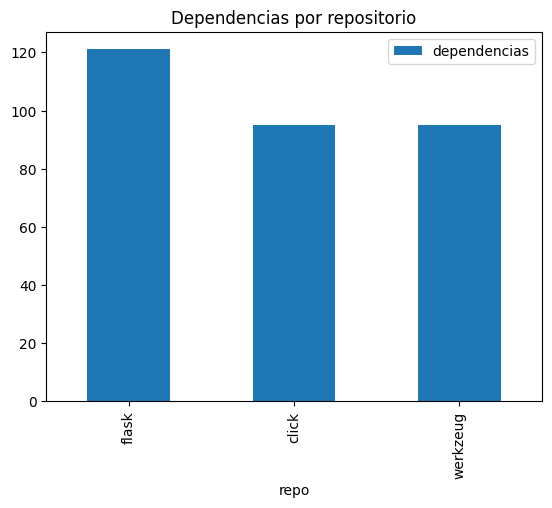

In [3]:
df.sort_values("dependencias", ascending=False).plot(
    kind="bar", x="repo", y="dependencias"
)

plt.xticks(rotation=90)
plt.title("Dependencias por repositorio")
plt.show()

In [4]:
vuln_data = []

for file in os.listdir("vulns"):
    with open(f"vulns/{file}") as f:
        v = json.load(f)
        
        for match in v.get("matches", []):
            vuln_data.append({
                "repo": file.replace(".json", ""),
                "severity": match["vulnerability"]["severity"]
            })

df_vuln = pd.DataFrame(vuln_data)
df_vuln.head()

,repo,severity
0,click,Medium
1,click,Low
2,flask,High
3,flask,Medium
4,flask,Medium


In [5]:
df_vuln["severity"].value_counts()

severity
Medium    14
Low        3
High       1
Name: count, dtype: int64

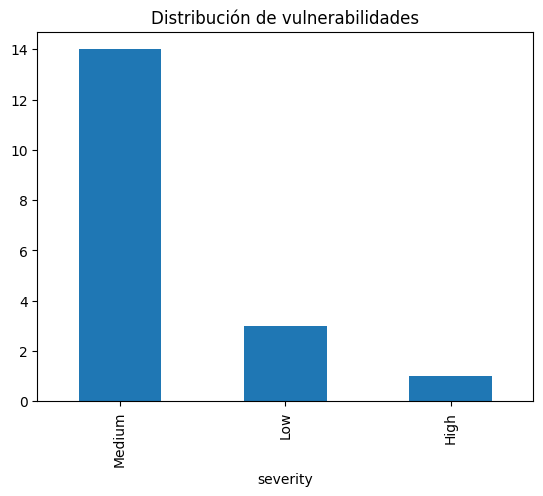

In [6]:
df_vuln["severity"].value_counts().plot(kind="bar")
plt.title("Distribución de vulnerabilidades")
plt.show()

In [7]:
df_vuln.groupby("repo").size().sort_values(ascending=False)

repo
flask    16
click     2
dtype: int64